In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('APL_Logistics.csv', encoding='latin1')
print("Data loaded successfully!")
print("Shape (rows, columns):", df.shape)

Data loaded successfully!
Shape (rows, columns): (180519, 40)


In [3]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']


In [4]:
pd.set_option('display.max_columns', None)
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [5]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [6]:
df['Late_delivery_risk'].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [7]:
df['Late_delivery_risk'].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [8]:
df['Late_delivery_risk'].value_counts(normalize=True) * 100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

In [9]:
mode_data = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
mode_data

Shipping Mode
First Class       95.322499
Same Day          45.743042
Second Class      76.632781
Standard Class    38.071683
Name: Late_delivery_risk, dtype: float64

In [10]:
region_data = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
region_data

Order Region
Central Africa     57.960644
South Asia         56.266977
East Africa        55.939525
Western Europe     55.848611
South of  USA      55.772559
Eastern Europe     55.663265
East of USA        55.661605
Southeast Asia     55.529930
Central Asia       55.334539
West Asia          55.283741
US Center          55.240360
Central America    54.754596
North Africa       54.517327
Southern Europe    54.384477
Eastern Asia       54.326923
South America      54.308671
Northern Europe    54.044118
Oceania            54.020497
West of USA        53.959715
Southern Africa    53.327571
Caribbean          53.077663
West Africa        52.840909
Canada             48.800834
Name: Late_delivery_risk, dtype: float64

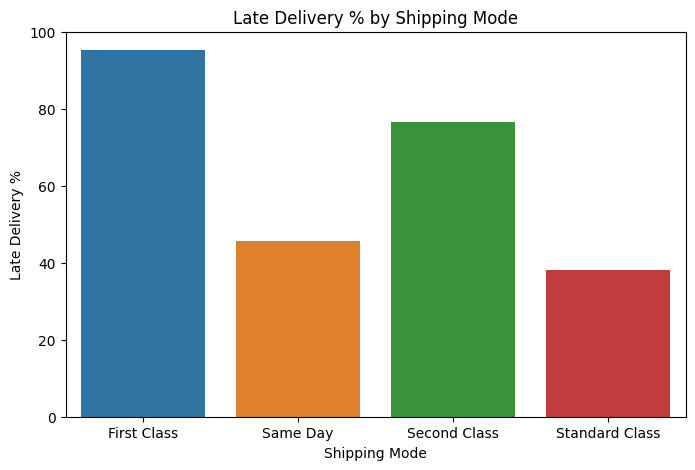

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x=mode_data.index, y=mode_data.values)
plt.title('Late Delivery % by Shipping Mode')
plt.ylabel('Late Delivery %')
plt.xlabel('Shipping Mode')
plt.show()

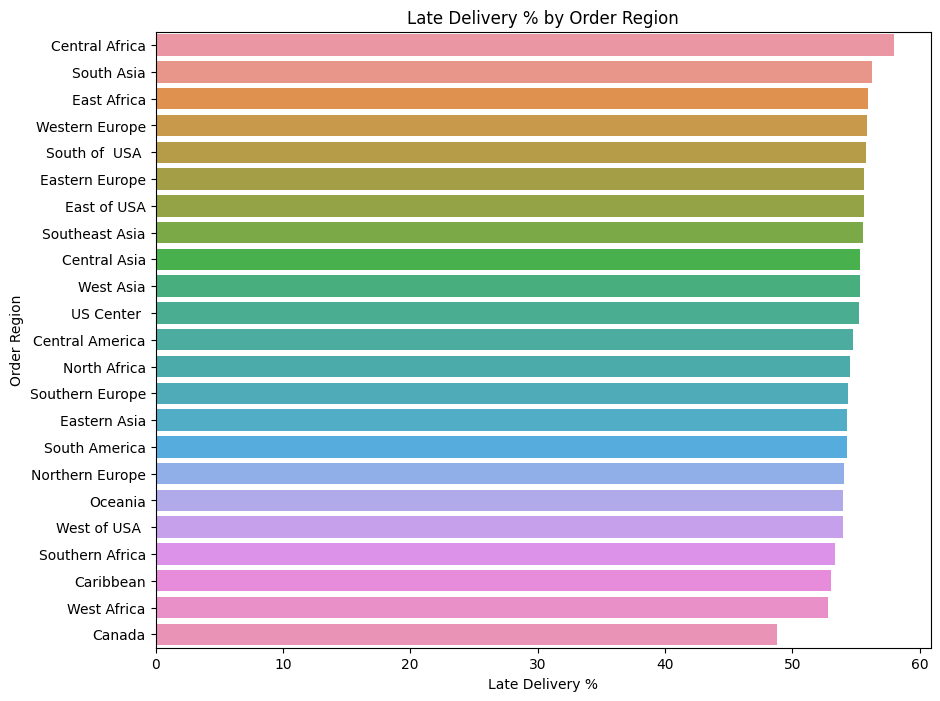

In [12]:
plt.figure(figsize=(10,8))
sns.barplot(x=region_data.values, y=region_data.index)
plt.title('Late Delivery % by Order Region')
plt.xlabel('Late Delivery %')
plt.ylabel('Order Region')
plt.show()

In [13]:
df = df.drop(columns=['Delivery Status', 'Days for shipping (real)'])
print("Columns dropped. New shape:", df.shape)

Columns dropped. New shape: (180519, 38)


In [14]:
print(df.columns.tolist())

['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']


In [15]:
columns_to_drop = ['Customer Fname', 'Customer Lname', 'Customer Street', 
                    'Customer Id', 'Order Customer Id', 
                    'Product Name', 'Customer Zipcode']

df = df.drop(columns=columns_to_drop)
print("Columns dropped. New shape:", df.shape)

Columns dropped. New shape: (180519, 31)


In [16]:
df.dtypes

Type                              object
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Segment                  object
Customer State                    object
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total

In [17]:
print(df.shape)

(180519, 31)


In [18]:
print(df.dtypes.to_string())

Type                              object
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Segment                  object
Customer State                    object
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total

In [19]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Shipping Mode']
Numerical: ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Department Id', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [20]:
for col in categorical_cols:
    print(col, "-->", df[col].nunique(), "unique categories")

Type --> 4 unique categories
Category Name --> 50 unique categories
Customer City --> 563 unique categories
Customer Country --> 2 unique categories
Customer Segment --> 3 unique categories
Customer State --> 46 unique categories
Department Name --> 11 unique categories
Market --> 5 unique categories
Order City --> 3597 unique categories
Order Country --> 164 unique categories
Order Region --> 23 unique categories
Order State --> 1089 unique categories
Order Status --> 9 unique categories
Shipping Mode --> 4 unique categories


In [21]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = ['Category Name', 'Customer City', 'Customer State', 
              'Department Name', 'Order City', 'Order Country', 
              'Order Region', 'Order State']

for col in label_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding done!")
print(df[label_cols].head())

Label Encoding done!
   Category Name  Customer City  Customer State  Department Name  Order City  \
0             10             61              40                5        2181   
1             38            276               6                6        2832   
2             46            276               6                3        2832   
3             46            276               6                3        2256   
4             47            276               6                6        2256   

   Order Country  Order Region  Order State  
0             69            13          610  
1             66             3          260  
2             66             3          260  
3             48             6          741  
4             48             6          741  


In [23]:
df = pd.get_dummies(df, columns=['Type', 'Customer Country', 'Customer Segment', 
                                  'Market', 'Shipping Mode', 'Order Status'])

print("One-Hot Encoding done!")
print("New shape:", df.shape)

One-Hot Encoding done!
New shape: (180519, 52)


In [24]:
print(df.columns.tolist())

['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer State', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product Price', 'Type_CASH', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Customer Country_EE. UU.', 'Customer Country_Puerto Rico', 'Customer Segment_Consumer', 'Customer Segment_Corporate', 'Customer Segment_Home Office', 'Market_Africa', 'Market_Europe', 'Market_LATAM', 'Market_Pacific Asia', 'Market_USCA', 'Shipping Mode_First Class', 'Shipping Mode_Same Day', 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class', 'Order Status_CANCELED', 'Order Status_CLOSED', 'Order Status_COMPLETE', 'Order Status_ON_HOLD

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ['Days for shipment (scheduled)', 'Benefit per order', 
              'Sales per customer', 'Category Id', 'Category Name',
              'Customer City', 'Customer State', 'Department Id',
              'Department Name', 'Latitude', 'Longitude', 'Order City',
              'Order Country', 'Order Item Discount', 'Order Item Discount Rate',
              'Order Item Product Price', 'Order Item Profit Ratio',
              'Order Item Quantity', 'Sales', 'Order Item Total',
              'Order Profit Per Order', 'Order Region', 'Order State',
              'Product Price']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaling done!")
print(df[scale_cols].head())

Scaling done!
   Days for shipment (scheduled)  Benefit per order  Sales per customer  \
0                       0.777152           1.318689            2.410316   
1                       0.777152           0.256001           -0.126184   
2                       0.777152           0.626094           -0.009310   
3                       0.777152          -0.611539           -0.059292   
4                       0.777152          -0.114666           -1.192133   

   Category Id  Category Name  Customer City  Customer State  Department Id  \
0    -1.461088      -1.181501      -0.826363        1.061090      -1.499753   
1    -0.182318       0.789732       0.509621       -1.544156      -0.272188   
2     1.032515       1.352941       0.509621       -1.544156       0.955377   
3     1.032515       1.352941       0.509621       -1.544156       0.955377   
4    -0.502010       1.423342       0.509621       -1.544156      -0.272188   

   Department Name  Latitude  Longitude  Order City  Order C

In [26]:
X = df.drop(columns=['Late_delivery_risk'])
y = df['Late_delivery_risk']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180519, 51)
y shape: (180519,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (144415, 51)
X_test shape: (36104, 51)
y_train shape: (144415,)
y_test shape: (36104,)


In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression training done!")

Logistic Regression training done!


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7101152226900066

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.91      0.74     16384
           1       0.88      0.54      0.67     19720

    accuracy                           0.71     36104
   macro avg       0.75      0.73      0.71     36104
weighted avg       0.77      0.71      0.70     36104


Confusion Matrix:
[[14983  1401]
 [ 9065 10655]]


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest training done!")

Random Forest training done!


In [31]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7712441834699756

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.87      0.78     16384
           1       0.87      0.69      0.77     19720

    accuracy                           0.77     36104
   macro avg       0.78      0.78      0.77     36104
weighted avg       0.79      0.77      0.77     36104


Confusion Matrix:
[[14280  2104]
 [ 6155 13565]]


In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost training done!")


XGBoost training done!


In [33]:
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7368712608021272

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.75     16384
           1       0.84      0.64      0.73     19720

    accuracy                           0.74     36104
   macro avg       0.75      0.75      0.74     36104
weighted avg       0.76      0.74      0.74     36104


Confusion Matrix:
[[13994  2390]
 [ 7110 12610]]


In [34]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values('Importance', ascending=False)

print(feature_importance.head(10))

                          Feature  Importance
0   Days for shipment (scheduled)    0.063622
41   Shipping Mode_Standard Class    0.061919
38      Shipping Mode_First Class    0.057253
9                        Latitude    0.056007
11                     Order City    0.052788
10                      Longitude    0.051519
22                    Order State    0.046786
1               Benefit per order    0.040888
20         Order Profit Per Order    0.040712
16        Order Item Profit Ratio    0.035976


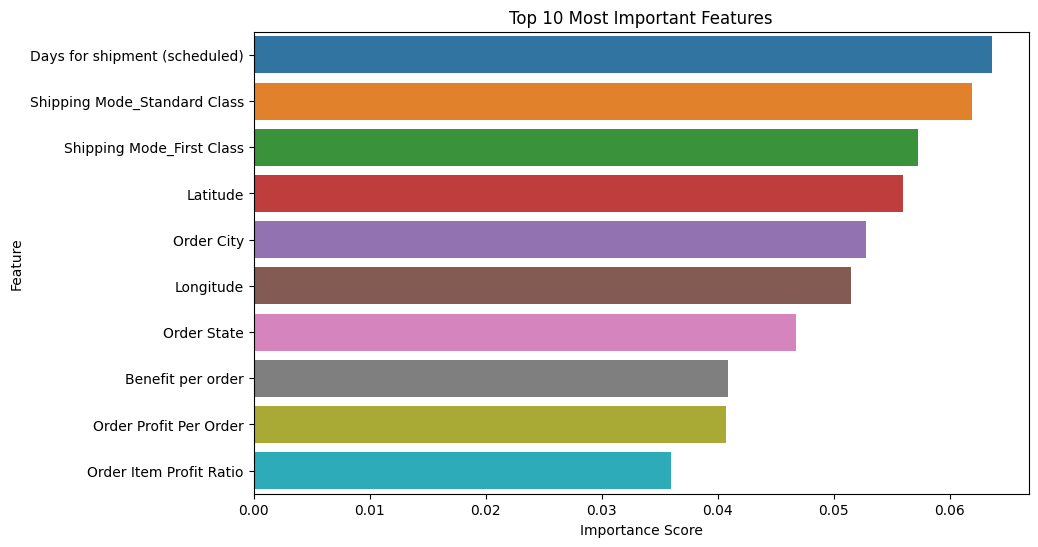

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance['Importance'].head(10), 
            y=feature_importance['Feature'].head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [36]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    'Late_Probability': y_pred_proba,
    'Actual': y_test.values
})

risk_df['Risk_Category'] = pd.cut(y_pred_proba, 
                                   bins=[0, 0.3, 0.7, 1.0],
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])

print(risk_df.head(10))
print("\nRisk Category Distribution:")
print(risk_df['Risk_Category'].value_counts())

   Late_Probability  Actual Risk_Category
0              0.33       0   Medium Risk
1              0.44       0   Medium Risk
2              0.42       0   Medium Risk
3              0.46       1   Medium Risk
4              0.56       0   Medium Risk
5              0.54       0   Medium Risk
6              0.97       1     High Risk
7              0.40       0   Medium Risk
8              0.54       1   Medium Risk
9              0.38       0   Medium Risk

Risk Category Distribution:
Risk_Category
Medium Risk    19966
High Risk      11027
Low Risk        4668
Name: count, dtype: int64


In [37]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pickle

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!
